In [1]:
from google.colab import files
from IPython.display import display, Markdown
import os
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

!pip install plotly -q

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

uploaded = files.upload()

csv_files = [file for file in os.listdir() if file.endswith(".csv")]

if len(csv_files) == 0:
    raise FileNotFoundError("No CSV file was uploaded.")

FILE_PATH = csv_files[0]
OUTPUT_DIR = "phase4_visualizations"

os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv(FILE_PATH)
df.columns = df.columns.astype(str).str.strip().str.lower()

important_numeric_cols = ["price", "year", "volume"]

for col in important_numeric_cols:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(" ", "", regex=False)
            .str.replace(",", ".", regex=False)
            .str.replace("₸", "", regex=False)
            .str.replace("тг", "", regex=False)
        )
        df[col] = pd.to_numeric(df[col], errors="coerce")

if "year" in df.columns:
    df["car_age"] = 2026 - df["year"]

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

print("=" * 80)
print("PHASE 4 DATA LOADED SUCCESSFULLY")
print("=" * 80)

print("Loaded file:", FILE_PATH)
print("Dataset shape:", df.shape)

display(df.head())
display(df.dtypes)

Saving kolesa.csv to kolesa.csv
PHASE 4 DATA LOADED SUCCESSFULLY
Loaded file: kolesa.csv
Dataset shape: (2754, 11)


,title,brand,model,price,year,body_type,volume,fuel,gearbox,type,car_age
0,BMW X5,BMW,X5,8000000,2013,кроссовер,3.00,бензин,автомат,Б/у,13
1,BMW 535,BMW,535,10500000,2012,седан,3.00,бензин,автомат,Б/у,14
2,BMW 528,BMW,528,1435555,1991,седан,2.80,бензин,механика,Б/у,35
3,BMW X5,BMW,X5,13500000,2014,кроссовер,3.00,бензин,автомат,Б/у,12
4,BMW 316,BMW,316,650000,1994,купе,1.60,бензин,механика,Б/у,32


,0
title,object
brand,object
model,object
price,int64
year,int64
body_type,object
volume,float64
fuel,object
gearbox,object
type,object


# Phase 4: Data Visualization

## Visualization 1: Price Distribution — Histogram

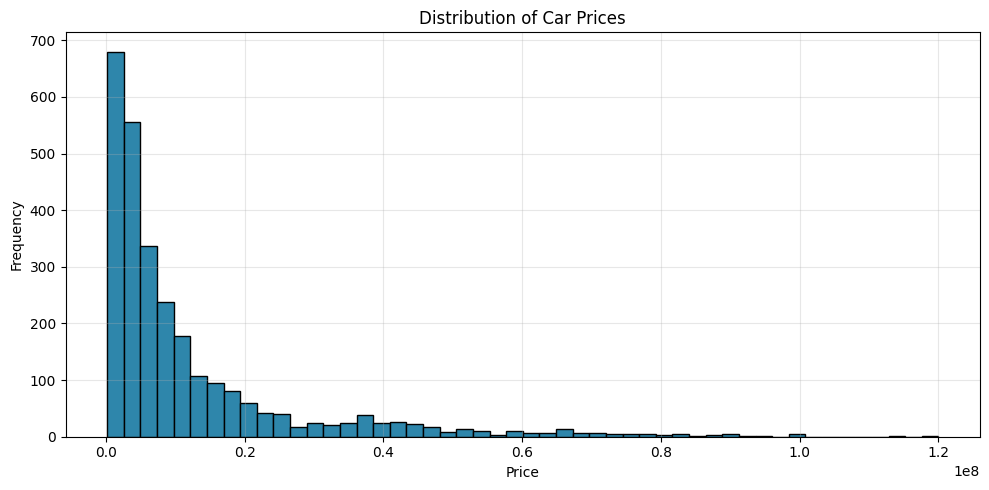

**Caption:** The price distribution is right-skewed. Most cars are concentrated in lower and middle price ranges, while a smaller number of cars are much more expensive.

## Visualization 2: Log Price Distribution — Histogram

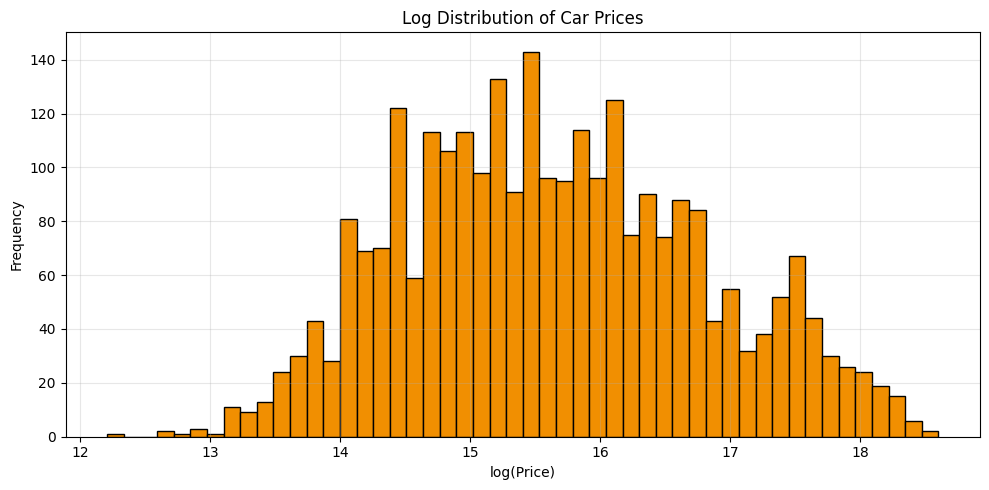

**Caption:** The log-transformed price distribution reduces the influence of extremely expensive cars and makes the overall distribution easier to interpret.

## Visualization 3: Price Outliers — Box Plot

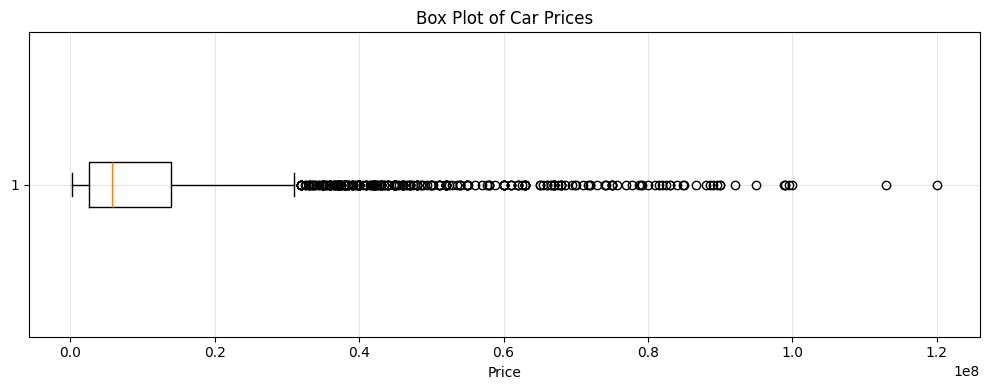

**Caption:** The box plot shows high-value outliers. These may represent premium, newer, or rare vehicles.

## Visualization 4: Price vs Year — Scatter Plot

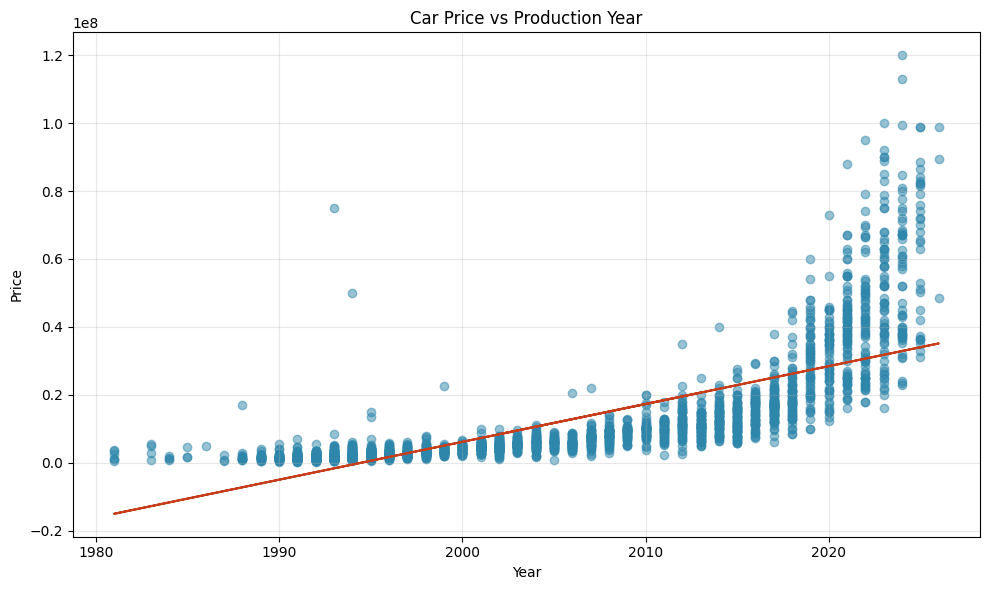

**Caption:** Newer cars generally tend to have higher prices. The trend line helps show whether production year is positively related to vehicle price.

## Visualization 5: Price vs Engine Volume — Scatter Plot

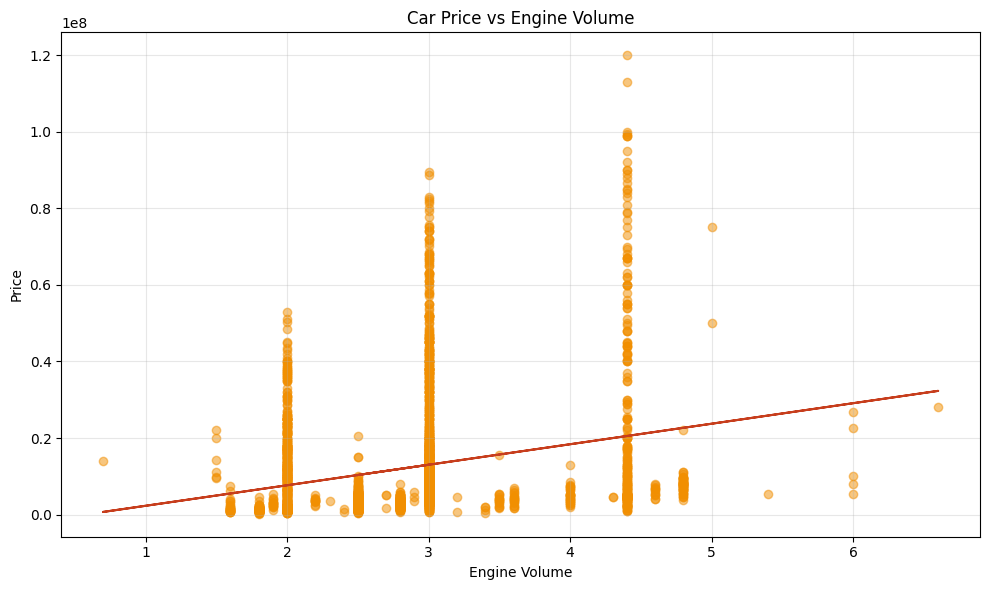

**Caption:** This scatter plot shows whether cars with larger engine volume tend to have higher prices.

## Visualization 6: Correlation Matrix — Heatmap

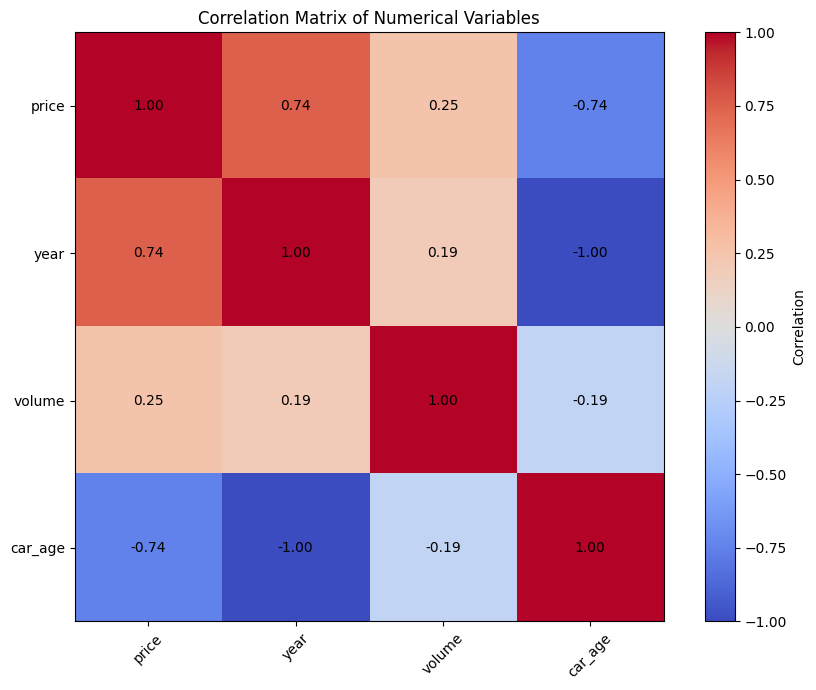

**Caption:** The heatmap shows relationships between numerical variables such as price, year, engine volume, and car age.

## Visualization 7: Average Price by Body Type — Bar Chart

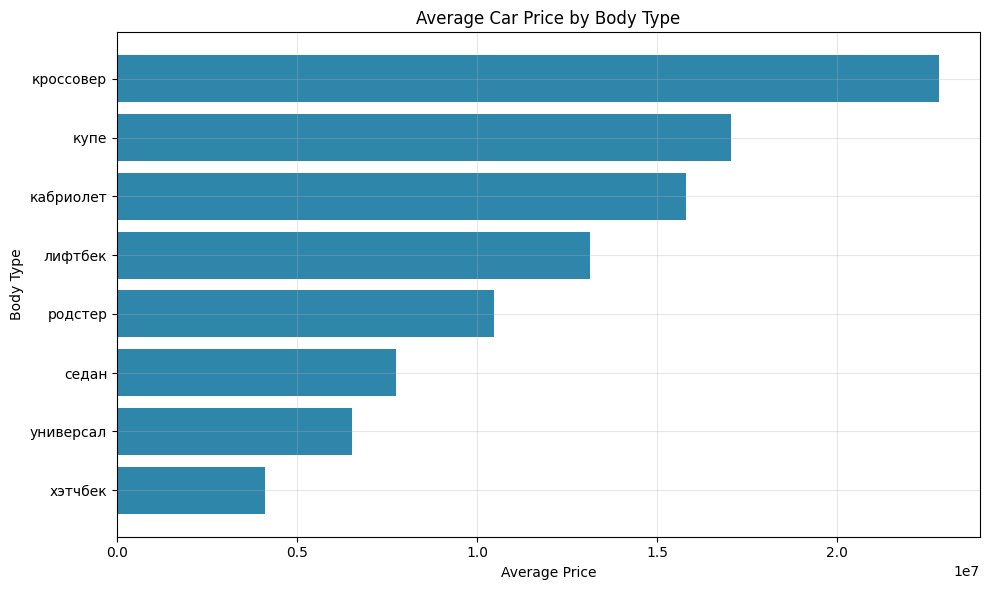

**Caption:** Average prices differ across body types. This suggests that vehicle body category is associated with market value.

## Visualization 8: Average Price by Fuel Type — Bar Chart

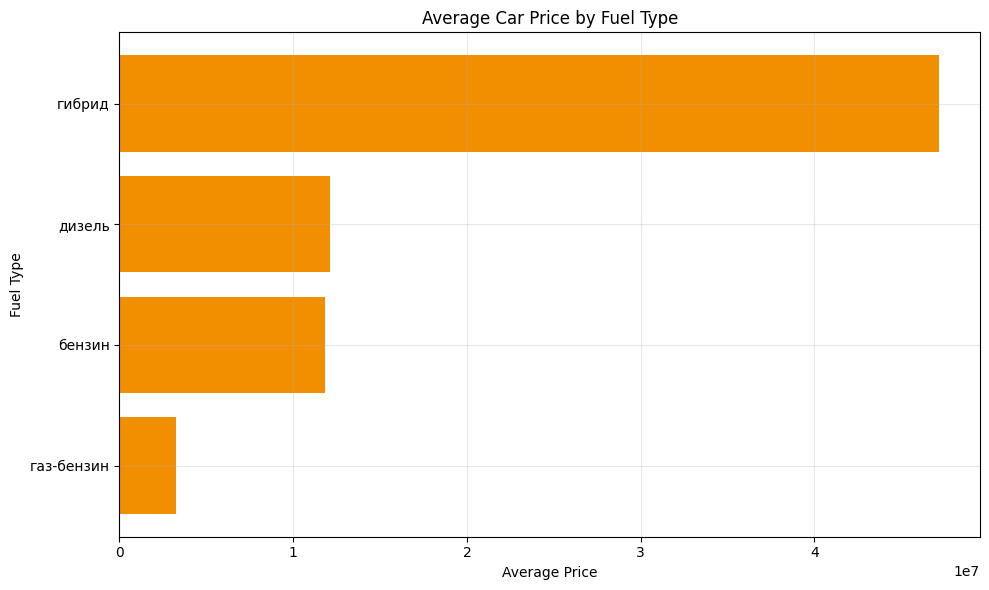

**Caption:** Average prices differ across fuel types. Fuel type may reflect vehicle segment, technology, and market positioning.

## Visualization 9: Average Price by Year — Line Chart

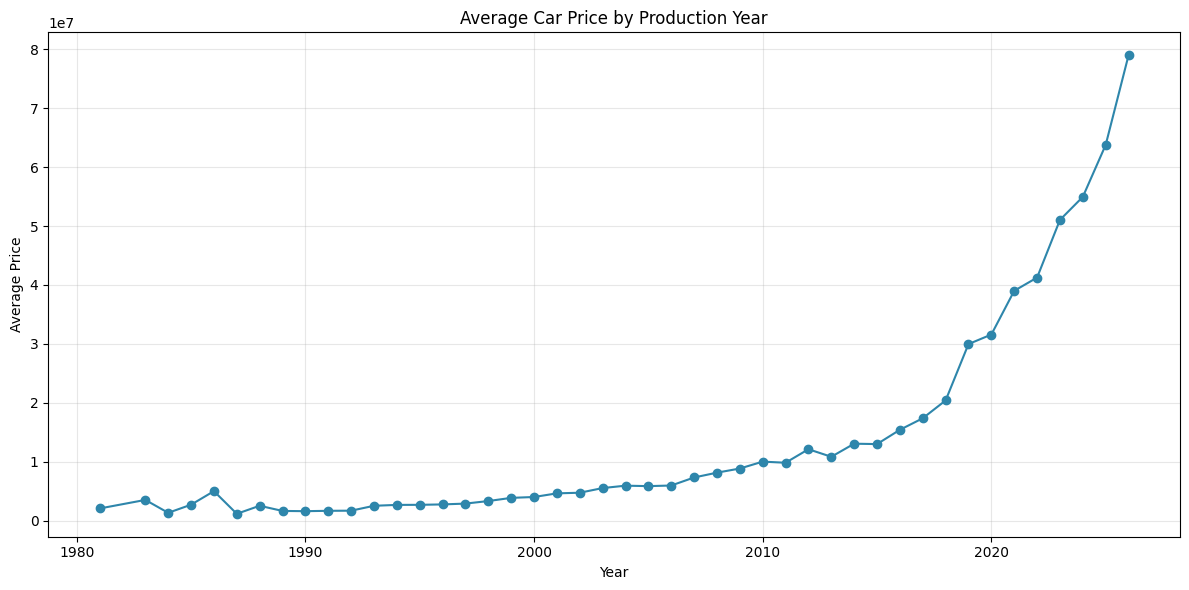

**Caption:** Average price generally increases for newer production years, which indicates that newer vehicles retain higher market value.

## Visualization 10: Number of Cars by Year — Line Chart

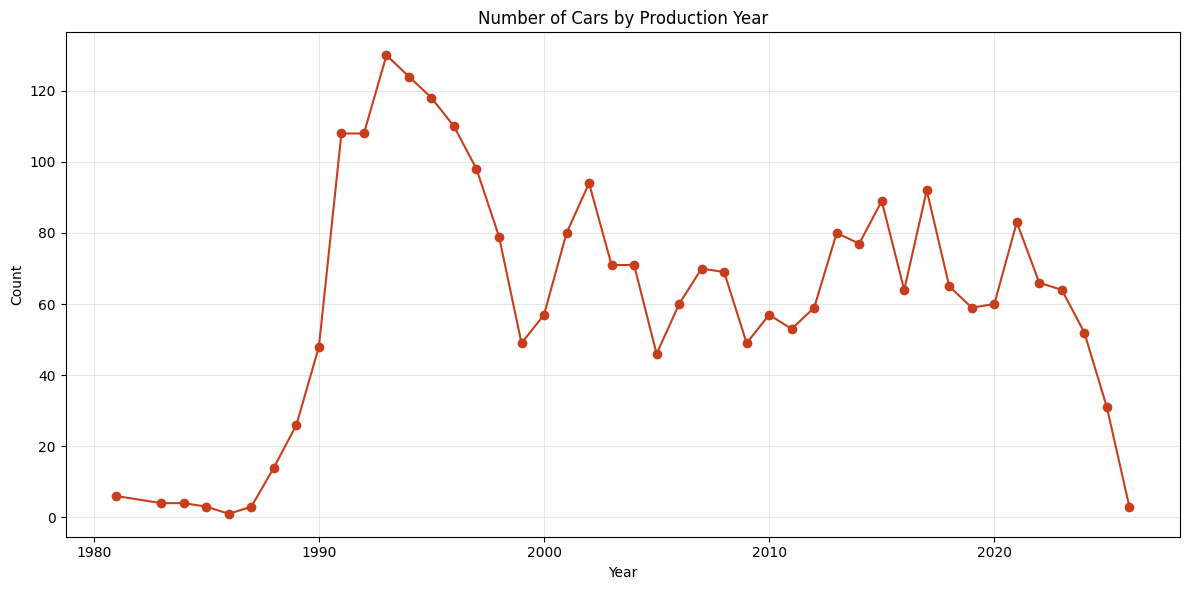

**Caption:** This line chart shows how many listings are available for each production year. It helps identify which model years are most common in the dataset.

## Visualization 11: Gearbox Type Share — Pie Chart

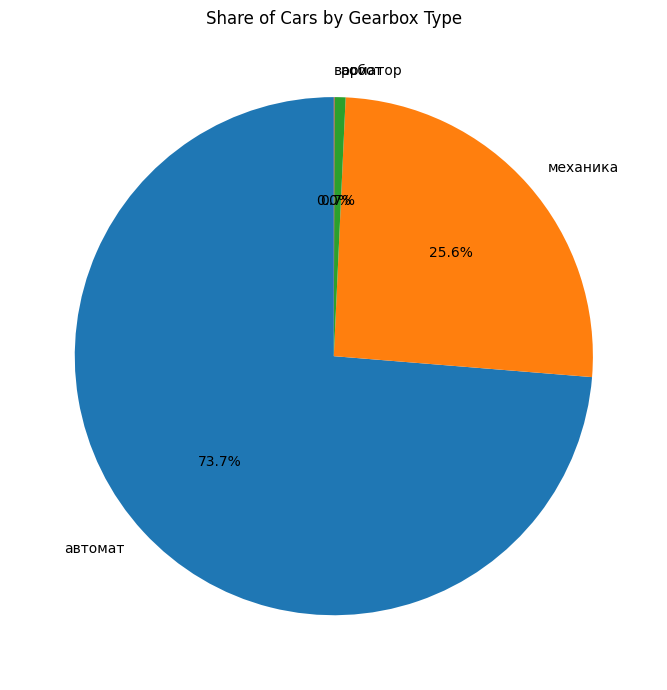

**Caption:** The pie chart shows the composition of transmission types in the dataset.

## Visualization 12: Price by Gearbox — Violin Plot

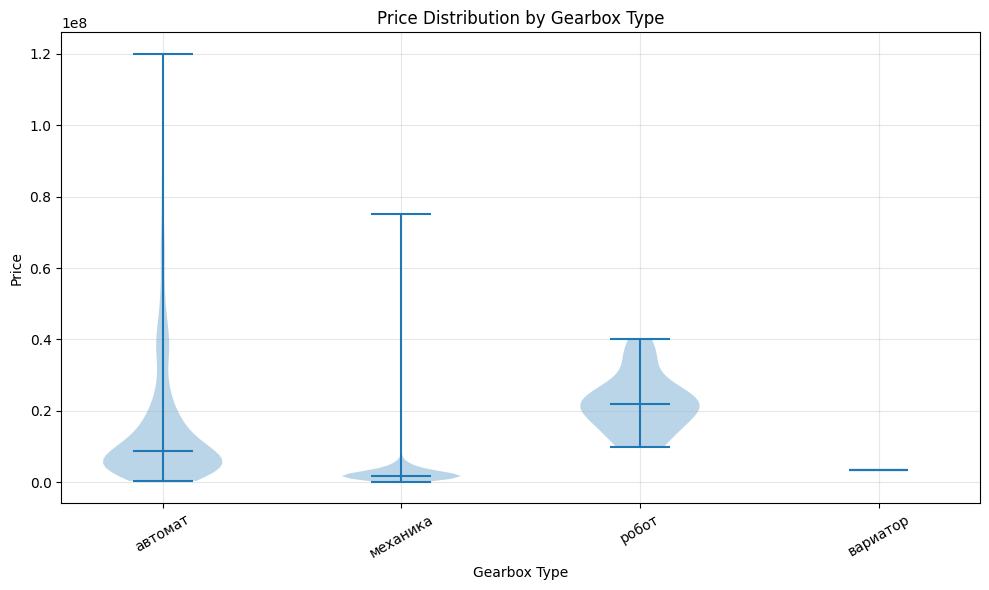

**Caption:** The violin plot compares price distributions across gearbox types. It shows both the spread and concentration of prices within each group.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

display(Markdown("# Phase 4: Data Visualization"))

main_color = "#2E86AB"
second_color = "#F18F01"
third_color = "#C73E1D"
green_color = "#4CAF50"


display(Markdown("## Visualization 1: Price Distribution — Histogram"))

price_data = df["price"].dropna()

plt.figure(figsize=(10, 5))
plt.hist(price_data, bins=50, edgecolor="black", color=main_color)
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

display(Markdown(
"**Caption:** The price distribution is right-skewed. Most cars are concentrated in lower and middle price ranges, while a smaller number of cars are much more expensive."
))

display(Markdown("## Visualization 2: Log Price Distribution — Histogram"))

plt.figure(figsize=(10, 5))
plt.hist(np.log1p(price_data), bins=50, edgecolor="black", color=second_color)
plt.title( "Log Distribution of Car Prices")
plt.xlabel("log(Price)")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

display(Markdown(
"**Caption:** The log-transformed price distribution reduces the influence of extremely expensive cars and makes the overall distribution easier to interpret."
))

display(Markdown("## Visualization 3: Price Outliers — Box Plot"))

plt.figure(figsize=(10, 4))
plt.boxplot(price_data, vert=False)
plt.title("Box Plot of Car Prices")
plt.xlabel("Price")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

display(Markdown(
"**Caption:** The box plot shows high-value outliers. These may represent premium, newer, or rare vehicles."
))


display(Markdown("## Visualization 4: Price vs Year — Scatter Plot"))

clean_data = df[["year", "price"]].dropna()

plt.figure(figsize=(10, 6))
plt.scatter(clean_data["year"], clean_data["price"], alpha=0.5, color=main_color)

if len(clean_data) > 1:
    z = np.polyfit(clean_data["year"], clean_data["price"], 1)
    p = np.poly1d(z)
    plt.plot(clean_data["year"], p(clean_data["year"]), color=third_color)

plt.title("Car Price vs Production Year")
plt.xlabel("Year")
plt.ylabel("Price")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

display(Markdown(
"**Caption:** Newer cars generally tend to have higher prices. The trend line helps show whether production year is positively related to vehicle price."
))

display(Markdown("## Visualization 5: Price vs Engine Volume — Scatter Plot"))

clean_data = df[["volume", "price"]].dropna()

plt.figure(figsize=(10, 6))
plt.scatter(clean_data["volume"], clean_data["price"], alpha=0.5, color=second_color)

if len(clean_data) > 1:
    z = np.polyfit(clean_data["volume"], clean_data["price"], 1)
    p = np.poly1d(z)
    plt.plot(clean_data["volume"], p(clean_data["volume"]), color=third_color)

plt.title("Car Price vs Engine Volume")
plt.xlabel("Engine Volume")
plt.ylabel("Price")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

display(Markdown(
"**Caption:** This scatter plot shows whether cars with larger engine volume tend to have higher prices."
))


display(Markdown("## Visualization 6: Correlation Matrix — Heatmap"))

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
plt.imshow(corr_matrix, cmap="coolwarm", interpolation="nearest")
plt.colorbar(label="Correlation")

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center")

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

display(Markdown(
"**Caption:** The heatmap shows relationships between numerical variables such as price, year, engine volume, and car age."
))


display(Markdown("## Visualization 7: Average Price by Body Type — Bar Chart"))

body_data = (
    df.groupby("body_type")
    .agg(mean_price=("price", "mean"), count=("price", "count"))
    .sort_values("mean_price", ascending=True)
)

plt.figure(figsize=(10, 6))
plt.barh(body_data.index.astype(str), body_data["mean_price"], color=main_color)
plt.title("Average Car Price by Body Type")
plt.xlabel("Average Price")
plt.ylabel("Body Type")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

display(Markdown(
"**Caption:** Average prices differ across body types. This suggests that vehicle body category is associated with market value."
))

display(Markdown("## Visualization 8: Average Price by Fuel Type — Bar Chart"))

fuel_data = (
    df.groupby("fuel")
    .agg(mean_price=("price", "mean"), count=("price", "count"))
    .sort_values("mean_price", ascending=True)
)

plt.figure(figsize=(10, 6))
plt.barh(fuel_data.index.astype(str), fuel_data["mean_price"], color=second_color)
plt.title("Average Car Price by Fuel Type")
plt.xlabel("Average Price")
plt.ylabel("Fuel Type")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

display(Markdown(
"**Caption:** Average prices differ across fuel types. Fuel type may reflect vehicle segment, technology, and market positioning."
))


display(Markdown("## Visualization 9: Average Price by Year — Line Chart"))

year_price = (
    df.groupby("year")
    .agg(mean_price=("price", "mean"), count=("price", "count"))
    .sort_index()
)

plt.figure(figsize=(12, 6))
plt.plot(year_price.index, year_price["mean_price"], marker="o", color=main_color)
plt.title("Average Car Price by Production Year")
plt.xlabel("Year")
plt.ylabel("Average Price")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

display(Markdown(
"**Caption:** Average price generally increases for newer production years, which indicates that newer vehicles retain higher market value."
))


display(Markdown("## Visualization 10: Number of Cars by Year — Line Chart"))

year_count = (
    df.groupby("year")
    .agg(count=("price", "count"))
    .sort_index()
)

plt.figure(figsize=(12, 6))
plt.plot(year_count.index, year_count["count"], marker="o", color=third_color)
plt.title("Number of Cars by Production Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

display(Markdown(
"**Caption:** This line chart shows how many listings are available for each production year. It helps identify which model years are most common in the dataset."
))


display(Markdown("## Visualization 11: Gearbox Type Share — Pie Chart"))

gearbox_counts = df["gearbox"].dropna().value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    gearbox_counts,
    labels=gearbox_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Share of Cars by Gearbox Type")
plt.tight_layout()
plt.show()

display(Markdown(
"**Caption:** The pie chart shows the composition of transmission types in the dataset."
))



display(Markdown("## Visualization 12: Price by Gearbox — Violin Plot"))

gearbox_price_clean = df.dropna(subset=["gearbox", "price"])

gearbox_categories = gearbox_price_clean["gearbox"].unique()

data_for_violin = [
    gearbox_price_clean[gearbox_price_clean["gearbox"] == category]["price"]
    for category in gearbox_categories
]

plt.figure(figsize=(10, 6))
plt.violinplot(data_for_violin, showmedians=True)
plt.xticks(range(1, len(gearbox_categories) + 1), gearbox_categories, rotation=30)
plt.title("Price Distribution by Gearbox Type")
plt.xlabel("Gearbox Type")
plt.ylabel("Price")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

display(Markdown(
"**Caption:** The violin plot compares price distributions across gearbox types. It shows both the spread and concentration of prices within each group."
))

# Summary Dashboard

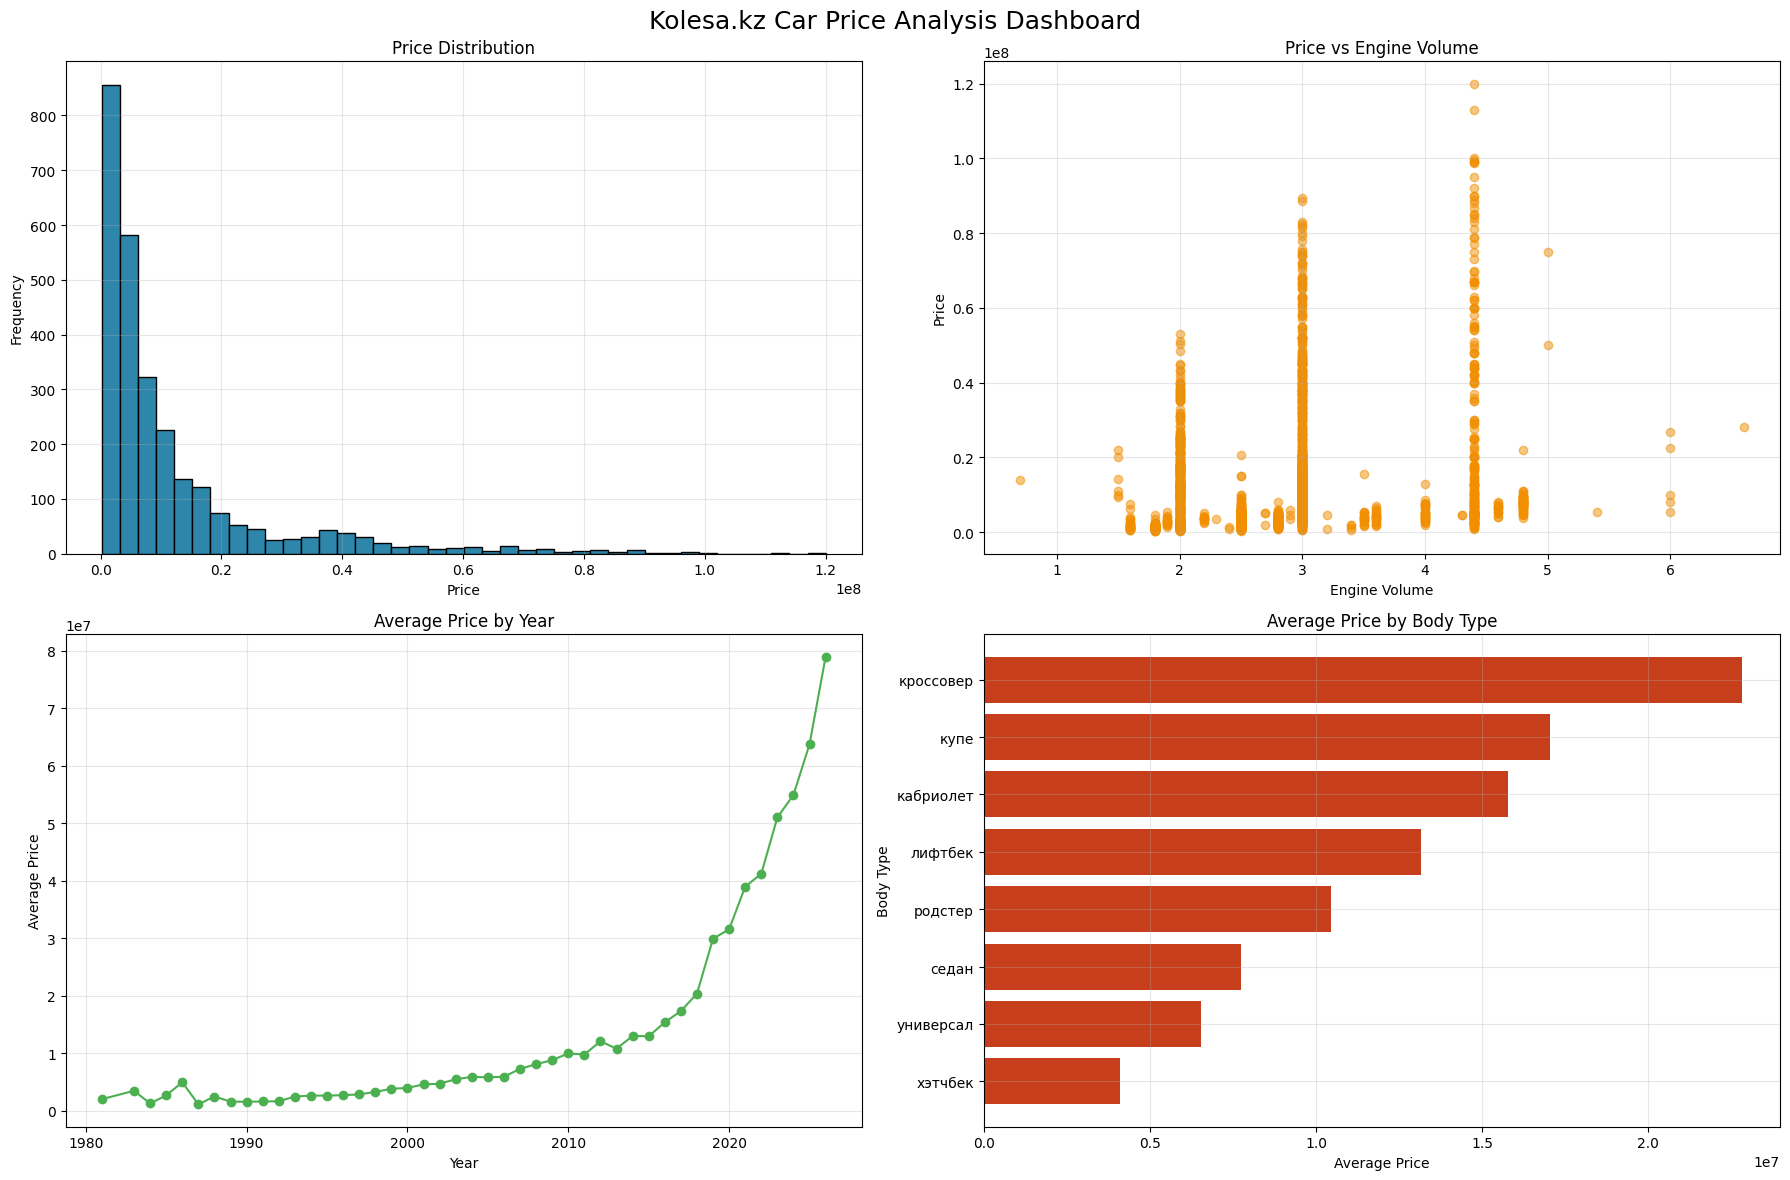

**Caption:** This dashboard summarizes the main findings: price distribution, the relationship between engine volume and price, price trends by year, and price differences by body type.

In [3]:

display(Markdown("# Summary Dashboard"))

fig, axes = plt.subplots(2, 2, figsize=(18, 12))


axes[0, 0].hist(df["price"].dropna(), bins=40, edgecolor="black", color=main_color)
axes[0, 0].set_title("Price Distribution")
axes[0, 0].set_xlabel("Price")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].grid(True, alpha=0.3)

clean_data = df[["volume", "price"]].dropna()
axes[0, 1].scatter(clean_data["volume"], clean_data["price"], alpha=0.5, color=second_color)
axes[0, 1].set_title("Price vs Engine Volume")
axes[0, 1].set_xlabel("Engine Volume")
axes[0, 1].set_ylabel("Price")
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(year_price.index, year_price["mean_price"], marker="o", color=green_color)
axes[1, 0].set_title("Average Price by Year")
axes[1, 0].set_xlabel("Year")
axes[1, 0].set_ylabel("Average Price")
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].barh(body_data.index.astype(str), body_data["mean_price"], color=third_color)
axes[1, 1].set_title("Average Price by Body Type")
axes[1, 1].set_xlabel("Average Price")
axes[1, 1].set_ylabel("Body Type")
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle("Kolesa.kz Car Price Analysis Dashboard", fontsize=18)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/17_summary_dashboard.png", dpi=300)
plt.show()

display(Markdown(
"**Caption:** This dashboard summarizes the main findings: price distribution, the relationship between engine volume and price, price trends by year, and price differences by body type."
))